# 14: Hidden Representation Learning with GIN

Many causal discovery examples assume every important variable is observed directly. Real datasets are often messier. We may observe several noisy measurements of a hidden construct, but not the construct itself. For example, a latent state such as user need, satisfaction, health status, or product-market fit may only appear through multiple proxy measurements.

We introduce the `causal-learn` GIN tools for linear non-Gaussian latent-variable models. GIN stands for **Generalized Independent Noise**. The practical idea is to use observed proxy variables to recover latent clusters and a causal order among latent constructs under strong structural assumptions.

We will simulate a small dataset with two hidden variables and six observed indicators. Then we will run `GIN_MI`, compare it with the independence-test version of GIN, evaluate recovered clusters against known truth, and stress-test the method when indicators become noisy or cross-loaded.

Estimated runtime: about 1-2 minutes. The baseline is fast; the sensitivity grid runs several small GIN fits.


## Learning Goals

By the end, you should be able to:

- explain why latent-variable discovery is different from observed-variable DAG discovery;
- simulate a linear non-Gaussian latent-variable model with observed indicators;
- run `causal-learn`'s GIN implementation and read the returned clusters;
- evaluate recovered latent clusters with cluster purity and adjusted Rand index;
- distinguish cluster recovery from latent causal ordering;
- recognize failure modes such as weak indicators, noisy indicators, and cross-loadings.


## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use synthetic graph-discovery datasets with known structural equations and known graph truth to study **Hidden Representation Learning With GIN**. Known graph truth lets us see when an algorithm recovers edges, misses edges, or invents edges under violated assumptions.

Read each row as a draw from a structural causal system. Columns are observed variables, and in some lessons omitted latent variables, environments, time ordering, or non-Gaussian mechanisms are deliberately introduced. The experiment studies latent representation discovery. Indicators are useful only when the measurement structure supports the hidden-factor story.

The goal is to learn what each discovery method assumes and how its output should be audited.


## Mathematical Foundation

<!-- math-foundation-note -->

Latent-variable discovery assumes observed indicators are generated from lower-dimensional hidden causes. A simple measurement structure is

$$
X_{jk}=\lambda_{jk}H_j+\eta_{jk}.
$$

Here $H_j$ is a latent factor and $X_{jk}$ is an observed indicator. Learning among indicators is not the same as learning among the latent constructs they measure.



We will work in a sequence that mirrors a careful applied workflow:

1. Set up imports, outputs, and plotting style.
2. Define a latent-variable data-generating process with known truth.
3. Audit observed indicators and their correlation structure.
4. Draw the true latent measurement graph.
5. Run `GIN_MI` and inspect the learned latent clusters.
6. Compare learned clusters with true latent groups.
7. Compare `GIN_MI` with the independence-test version of GIN.
8. Run sensitivity checks for sample size, measurement noise, latent noise shape, and cross-loading.
9. Save reporting guidance.


## Why Hidden Representation Learning Matters

Observed-variable graph discovery asks for edges among measured columns. Hidden representation learning asks a different question: which unobserved constructs could explain groups of measured columns, and how might those constructs be causally ordered?

This matters because proxy variables measure a construct only indirectly. If three indicators all measure the same hidden factor, drawing causal arrows among those indicators can be misleading. A latent-variable view says: these observed variables are children of a hidden parent, and the hidden parent is the object we may want to reason about.





## Tutorial Workflow

### GIN in Plain Language

GIN-style methods are designed for linear non-Gaussian latent-variable models. The observed variables are generated from hidden variables plus independent noise. Under the right assumptions, certain linear combinations of observed indicators should be independent of variables outside the indicator group. GIN uses this property to find clusters of indicators and then infer a causal order among the latent variables.

Two details are important:

- GIN is not a generic clustering algorithm. It relies on causal and distributional assumptions.
- The output latent labels such as `L1` and `L2` are discovered labels, not the original names from the simulator. We must map them back to truth using their observed indicators.


### What GIN Can and Cannot Claim

GIN can suggest that a set of observed variables share a latent parent, and it can propose an order among recovered latent groups. In this lesson, we can score that proposal because the synthetic truth is known.

In real data, the learned latent graph should be treated as a candidate measurement structure. Stronger claims require domain review, alternative specifications, sensitivity checks, and preferably external validation. Cross-loaded indicators, weak proxies, hidden subgroups, nonlinear measurement, and Gaussian noise can all make the output less reliable.


#### Setup

The code below imports the packages used in the lesson and creates output folders. The matplotlib cache path avoids noisy cache warnings in restricted environments.


In [1]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import time
import warnings
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "causal_learn":
    PROJECT_ROOT = PROJECT_ROOT.parents[2]
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "causal_learn" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MATPLOTLIB_CACHE_DIR = OUTPUT_DIR / "matplotlib_cache"
for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, MATPLOTLIB_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MATPLOTLIB_CACHE_DIR))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*")
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from IPython.display import display
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler
from causallearn.search.HiddenCausal.GIN.GIN import GIN, GIN_MI
NOTEBOOK_PREFIX = "14"
RANDOM_SEED = 42
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160})
print(f"Project root: {PROJECT_ROOT}")
print(f"Outputs: {OUTPUT_DIR}")


Project root: repository root
Outputs: notebooks/tutorials/causal_learn/outputs


The output paths follow the same convention as the earlier tutorial lessons. Every file created here begins with `14_`.

This reproducibility check keeps the run auditable before causal interpretation begins. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->


#### Package Versions

Version tracking is useful because latent discovery methods combine numerical linear algebra, independence testing, and graph conventions.


In [2]:
import causallearn
import sklearn
version_table = pd.DataFrame(
    [
        {"package": "numpy", "version": np.__version__},
        {"package": "pandas", "version": pd.__version__},
        {"package": "scikit-learn", "version": sklearn.__version__},
        {"package": "causal-learn", "version": getattr(causallearn, "__version__", "not exposed")},
    ]
)
version_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_package_versions.csv", index=False)
display(version_table)


,package,version
0,numpy,2.4.4
1,pandas,3.0.2
2,scikit-learn,1.6.1
3,causal-learn,not exposed


Saving these versions makes it easier to reproduce the exact graph and cluster outputs later.

This reproducibility check keeps the run auditable before causal interpretation begins. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->


### Define the Latent Measurement Model

The synthetic dataset has two hidden variables:

- `latent_need`: an upstream hidden construct;
- `latent_value`: a downstream hidden construct caused by `latent_need`.

Each latent variable has three observed indicators. The observed indicators are noisy measurements, not causes of each other. This is exactly the kind of setting where an observed-variable graph can be less natural than a latent measurement graph.


In [3]:
OBSERVED_VARIABLES = [
    "X1_need_search",
    "X2_need_depth",
    "X3_need_variety",
    "X4_value_click",
    "X5_value_watch",
    "X6_value_return",
]
OBSERVED_LABELS = [f"X{i}" for i in range(1, len(OBSERVED_VARIABLES) + 1)]
OBSERVED_NAME_MAP = dict(zip(OBSERVED_LABELS, OBSERVED_VARIABLES))
TRUE_LATENT_GROUPS = {
    "latent_need": [0, 1, 2],
    "latent_value": [3, 4, 5],
}
TRUE_LATENT_ORDER = ["latent_need", "latent_value"]
TRUE_CLUSTER_LABELS = np.array([0, 0, 0, 1, 1, 1])
indicator_metadata = pd.DataFrame(
    [
        {
            "observed_index": i,
            "gin_label": f"X{i + 1}",
            "observed_variable": OBSERVED_VARIABLES[i],
            "true_latent": latent,
        }
        for latent, members in TRUE_LATENT_GROUPS.items()
        for i in members
    ]
).sort_values("observed_index")
indicator_metadata.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_indicator_metadata.csv", index=False)
display(indicator_metadata)


,observed_index,gin_label,observed_variable,true_latent
0,0,X1,X1_need_search,latent_need
1,1,X2,X2_need_depth,latent_need
2,2,X3,X3_need_variety,latent_need
3,3,X4,X4_value_click,latent_value
4,4,X5,X5_value_watch,latent_value
5,5,X6,X6_value_return,latent_value


This metadata table is essential because `causal-learn` labels observed variables as `X1`, `X2`, and so on. The table maps those algorithm labels back to meaningful column names.


#### Simulate Latent Indicator Data

The simulator creates non-Gaussian hidden variables and non-Gaussian measurement noise. The downstream latent variable depends on the upstream latent variable. Each observed indicator is a noisy linear measurement of its own latent parent.

The function also has knobs for later stress tests: higher measurement noise, Gaussian noise, weak indicators, and cross-loading from the wrong latent factor.


In [4]:
# Define reusable helpers for the Simulate Latent Indicator Data section.
def draw_noise(rng, distribution, scale, size):
    """
    Idea: Generate noise from the requested family so robustness checks can compare data-generating conditions.
    
    Parameters
    ----------
    rng : np.random.Generator
        Random generator that makes the simulation reproducible.
    distribution : object
        Noise distribution or data distribution used in the simulation.
    scale : float
        Scale parameter for noise or plotting.
    size : int or tuple
        Number of generated values or shape of a generated array.
    
    Returns
    -------
    np.ndarray
        Noise vector drawn from the requested distribution and scale.
    """
    if distribution == "laplace":
        return rng.laplace(loc=0.0, scale=scale, size=size)
    if distribution == "gaussian":
        return rng.normal(loc=0.0, scale=scale, size=size)
    raise ValueError(f"Unknown distribution: {distribution}")
def simulate_latent_indicator_data(
    n_samples=500,
    seed=RANDOM_SEED,
    measurement_noise=0.25,
    latent_noise_distribution="laplace",
    weak_value_indicators=False,
    cross_loading_strength=0.0,
):
    """
    Simulate two latent variables and six observed indicators.
    
    Parameters
    ----------
    n_samples : int
        Number of observations generated, sampled, or evaluated.
    seed : int
        Random seed for reproducible simulation or resampling.
    measurement_noise : object
        Noise level in the observed indicators of the latent-variable simulation.
    latent_noise_distribution : object
        Distribution used for latent-variable noise in the GIN simulation.
    weak_value_indicators : object
        Whether weak indicators are included in the latent-measurement design.
    cross_loading_strength : object
        Strength of cross-loadings between latent factors and observed indicators.
    
    Returns
    -------
    tuple
        Tuple containing observed_df, latent_df, loading_df.
    """
    rng = np.random.default_rng(seed)
    latent_need = draw_noise(rng, latent_noise_distribution, scale=1.0, size=n_samples)
    latent_value = 0.80 * latent_need + draw_noise(rng, latent_noise_distribution, scale=0.80, size=n_samples)
    indicator_rows = []
    observed_columns = []
    latent_values = {"latent_need": latent_need, "latent_value": latent_value}
    loadings = {
        "latent_need": [1.00, 0.85, 1.15],
        "latent_value": [1.00, 0.85, 1.15] if not weak_value_indicators else [1.00, 0.25, 0.20],
    }
    for latent_name, member_indices in TRUE_LATENT_GROUPS.items():
        latent = latent_values[latent_name]
        for local_position, observed_index in enumerate(member_indices):
            loading = loadings[latent_name][local_position]
            indicator = loading * latent + draw_noise(rng, latent_noise_distribution, scale=measurement_noise, size=n_samples)
            if latent_name == "latent_value" and local_position == 2 and cross_loading_strength > 0:
                indicator = indicator + cross_loading_strength * latent_need
            observed_columns.append(indicator)
            indicator_rows.append(
                {
                    "observed_index": observed_index,
                    "observed_variable": OBSERVED_VARIABLES[observed_index],
                    "true_latent": latent_name,
                    "loading": loading,
                    "cross_loading_from_latent_need": cross_loading_strength if latent_name == "latent_value" and local_position == 2 else 0.0,
                }
            )
    observed = np.column_stack(observed_columns)
    observed = StandardScaler().fit_transform(observed)
    observed_df = pd.DataFrame(observed, columns=OBSERVED_VARIABLES)
    latent_df = pd.DataFrame(latent_values)
    loading_df = pd.DataFrame(indicator_rows).sort_values("observed_index")
    return observed_df, latent_df, loading_df
observed_df, latent_df, loading_df = simulate_latent_indicator_data()
observed_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_synthetic_observed_indicators.csv", index=False)
latent_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_synthetic_latent_truth.csv", index=False)
loading_df.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_true_indicator_loadings.csv", index=False)
display(observed_df.head())
display(loading_df)


,X1_need_search,X2_need_depth,X3_need_variety,X4_value_click,X5_value_watch,X6_value_return
0,0.210734,0.674549,0.798217,0.312065,0.932810,0.726086
1,-0.107946,0.452515,-0.094703,0.766822,0.733792,0.730695
2,0.700340,0.864484,1.342414,1.947996,1.436003,0.682666
3,0.160189,0.332632,0.452165,0.438866,0.401892,0.322598
4,-1.189448,-1.021969,-1.457619,-0.903877,-1.103179,-0.748391


,observed_index,observed_variable,true_latent,loading,cross_loading_from_latent_need
0,0,X1_need_search,latent_need,1.00,0.0
1,1,X2_need_depth,latent_need,0.85,0.0
2,2,X3_need_variety,latent_need,1.15,0.0
3,3,X4_value_click,latent_value,1.00,0.0
4,4,X5_value_watch,latent_value,0.85,0.0
5,5,X6_value_return,latent_value,1.15,0.0


The observed dataset contains only indicators. The latent truth is saved for evaluation, but the GIN algorithm only receives the observed indicator matrix.

The later estimates should be read in light of this sample construction, since data quality and composition set the boundary for any causal claim.
<!-- result-implication-expanded -->





## Diagnostics and Interpretation

### Basic Data Audit

Before any latent discovery step, inspect observed indicator scale and missingness. GIN expects a numeric matrix with no missing values.


In [5]:
data_audit = pd.DataFrame(
    {
        "mean": observed_df.mean(),
        "std": observed_df.std(),
        "min": observed_df.min(),
        "max": observed_df.max(),
        "missing_rate": observed_df.isna().mean(),
    }
).reset_index(names="observed_variable")
data_audit.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_data_audit.csv", index=False)
display(data_audit.round(3))


,observed_variable,mean,std,min,max,missing_rate
0,X1_need_search,-0.0,1.001,-3.415,4.856,0.0
1,X2_need_depth,0.0,1.001,-3.350,4.999,0.0
2,X3_need_variety,0.0,1.001,-3.672,5.048,0.0
3,X4_value_click,0.0,1.001,-2.871,3.827,0.0
4,X5_value_watch,0.0,1.001,-3.111,4.065,0.0
5,X6_value_return,0.0,1.001,-3.053,3.913,0.0


The indicators are standardized and complete. That keeps the focus on latent structure rather than preprocessing problems.

The later estimates should be read in light of this sample construction, since data quality and composition set the boundary for any causal claim.
<!-- result-implication-expanded -->


### Correlation Structure of Indicators

If the measurement model is clean, indicators of the same latent variable should be strongly correlated with each other. Indicators across different latent variables can also be correlated because the latent variables are causally connected.


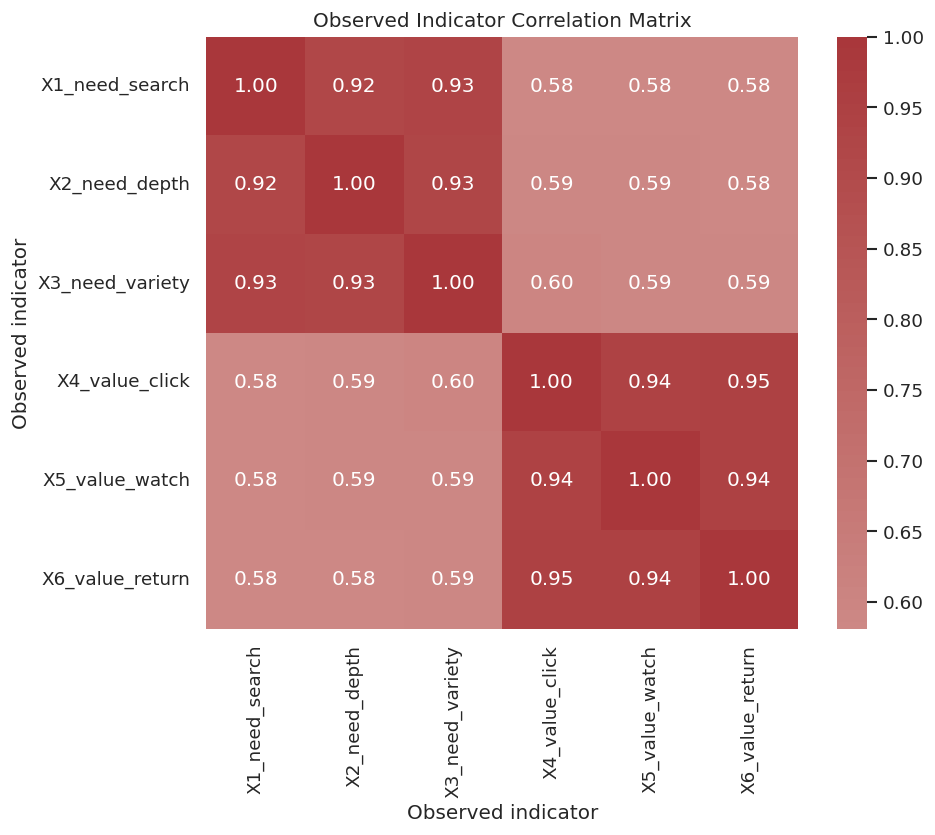

In [6]:
indicator_correlation = observed_df.corr()
indicator_correlation.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_indicator_correlation.csv")
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(indicator_correlation, cmap="vlag", center=0, annot=True, fmt=".2f", square=True, ax=ax)
ax.set_title("Observed Indicator Correlation Matrix")
ax.set_xlabel("Observed indicator")
ax.set_ylabel("Observed indicator")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_indicator_correlation_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()


The block pattern is visible: the first three indicators move together, and the last three indicators move together. Cross-block correlation is also present because the upstream latent factor causes the downstream latent factor.




#### Draw the True Latent Measurement Graph

The true graph has latent variables at the top and observed indicators below. The measured columns are children of hidden parents, not peers in a simple observed-variable DAG.


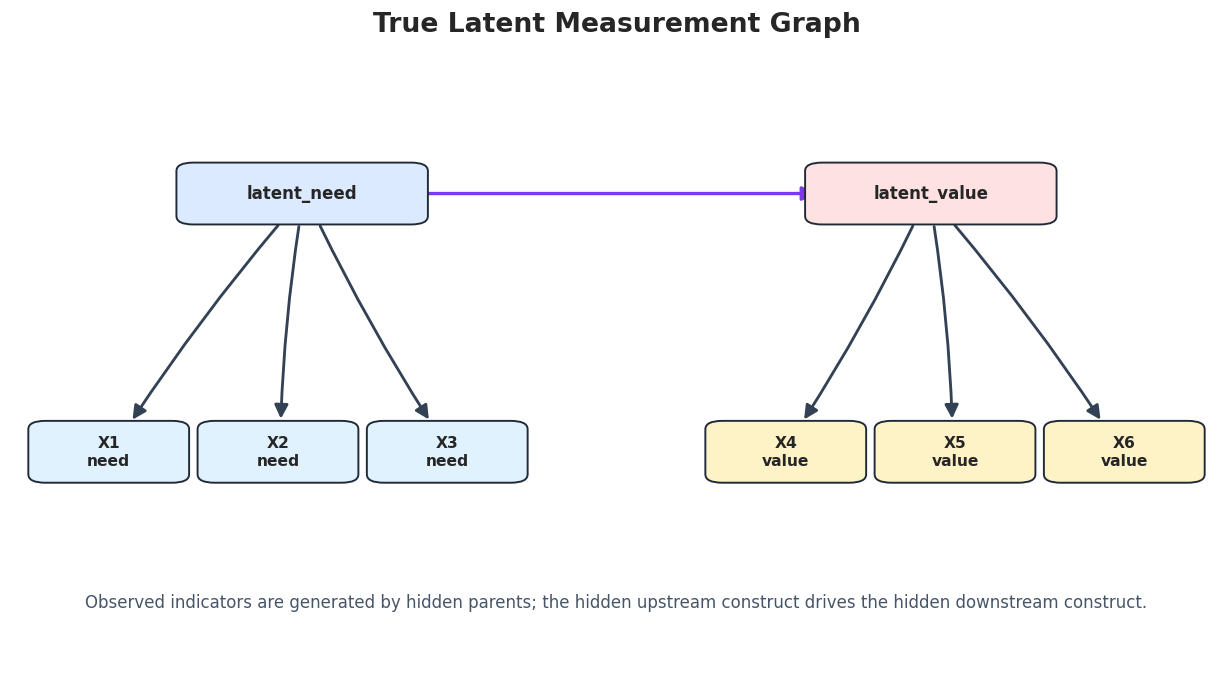

In [7]:
# Define reusable helpers for the Draw The True Latent Measurement Graph section.
def add_box(ax, xy, label, color, width=0.16, height=0.075, fontsize=10):
    """
    Idea: Add a labeled node box to a Matplotlib flowchart or graph diagram.
    
    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes object that receives the drawing commands.
    xy : object
        Coordinate pair used to place a plotted node, label, or annotation.
    label : str
        Short label attached to a scenario, method, or plotted result.
    color : str
        Plot color used to identify this element.
    width : float
        Width used for a plotted box or simulated object.
    height : float
        Height used for a plotted box or simulated object.
    fontsize : float
        Font size used for a label in the plot.
    
    Returns
    -------
    None
        Adds a labeled node box directly to the supplied Matplotlib axes.
    """
    x, y = xy
    patch = FancyBboxPatch(
        (x - width / 2, y - height / 2),
        width,
        height,
        boxstyle="round,pad=0.014",
        facecolor=color,
        edgecolor="#1f2937",
        linewidth=1.15,
        zorder=4,
    )
    ax.add_patch(patch)
    ax.text(x, y, label, ha="center", va="center", fontsize=fontsize, fontweight="bold", zorder=5)
def boundary_points(start, end, width=0.16, height=0.075, gap=0.012):
    """
    Idea: Move arrow start and end points to the visible boundary of two boxes.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate for a plotted element.
    end : tuple[float, float]
        Ending coordinate for a plotted element.
    width : float
        Width used for a plotted box or simulated object.
    height : float
        Height used for a plotted box or simulated object.
    gap : float
        Spacing used to keep plotted elements from overlapping.
    
    Returns
    -------
    tuple[tuple[float, float], tuple[float, float]]
        Adjusted start and end coordinates for an arrow between boxes.
    """
    x0, y0 = start
    x1, y1 = end
    dx = x1 - x0
    dy = y1 - y0
    distance = (dx**2 + dy**2) ** 0.5
    if distance == 0:
        return start, end
    ux, uy = dx / distance, dy / distance
    candidates = []
    if abs(ux) > 1e-9:
        candidates.append((width / 2) / abs(ux))
    if abs(uy) > 1e-9:
        candidates.append((height / 2) / abs(uy))
    offset = min(candidates) + gap
    return (x0 + ux * offset, y0 + uy * offset), (x1 - ux * offset, y1 - uy * offset)
def add_arrow(ax, start, end, color="#334155", rad=0.0, lw=1.7):
    """
    Idea: Add an arrow annotation to an existing Matplotlib axes.
    
    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes object that receives the drawing commands.
    start : tuple[float, float]
        Starting coordinate for a plotted element.
    end : tuple[float, float]
        Ending coordinate for a plotted element.
    color : str
        Plot color used to identify this element.
    rad : float
        Curvature parameter for the plotted arrow.
    lw : float
        Line width for the plotted arrow or edge.
    
    Returns
    -------
    None
        Adds an arrow annotation directly to the supplied Matplotlib axes.
    """
    start_edge, end_edge = boundary_points(start, end)
    arrow = FancyArrowPatch(
        start_edge,
        end_edge,
        arrowstyle="-|>",
        mutation_scale=17,
        linewidth=lw,
        color=color,
        connectionstyle=f"arc3,rad={rad}",
        zorder=2,
    )
    ax.add_patch(arrow)
def draw_true_measurement_graph(path):
    """
    Idea: Draw the oracle latent-measurement graph used to check the GIN example.
    
    Parameters
    ----------
    path : str or pathlib.Path
        Input or output path.
    
    Returns
    -------
    None
        Draws and saves the oracle latent-measurement graph.
    """
    fig, ax = plt.subplots(figsize=(13, 6.5))
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    positions = {
        "latent_need": (0.24, 0.78),
        "latent_value": (0.76, 0.78),
        "X1": (0.08, 0.35),
        "X2": (0.22, 0.35),
        "X3": (0.36, 0.35),
        "X4": (0.64, 0.35),
        "X5": (0.78, 0.35),
        "X6": (0.92, 0.35),
    }
    add_arrow(ax, positions["latent_need"], positions["latent_value"], color="#7c3aed", lw=2.0)
    for label in ["X1", "X2", "X3"]:
        add_arrow(ax, positions["latent_need"], positions[label], rad=0.03)
    for label in ["X4", "X5", "X6"]:
        add_arrow(ax, positions["latent_value"], positions[label], rad=-0.03)
    add_box(ax, positions["latent_need"], "latent_need", "#dbeafe", width=0.18)
    add_box(ax, positions["latent_value"], "latent_value", "#fee2e2", width=0.18)
    for label in ["X1", "X2", "X3"]:
        add_box(ax, positions[label], f"{label}\nneed", "#e0f2fe", width=0.105, fontsize=9.3)
    for label in ["X4", "X5", "X6"]:
        add_box(ax, positions[label], f"{label}\nvalue", "#fef3c7", width=0.105, fontsize=9.3)
    ax.text(
        0.5,
        0.10,
        "Observed indicators are generated by hidden parents; the hidden upstream construct drives the hidden downstream construct.",
        ha="center",
        va="center",
        fontsize=10,
        color="#475569",
    )
    ax.set_title("True Latent Measurement Graph", pad=18, fontsize=16, fontweight="bold")
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
draw_true_measurement_graph(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_true_latent_measurement_graph.png")


This is the graph we want the GIN workflow to recover at a high level: two indicator clusters and an upstream-to-downstream latent order.

For causal discovery, the result is a statement about recoverable structure under assumptions, not a free-standing proof of cause and effect.
<!-- result-implication-expanded -->


#### Helper Functions for GIN Output

`GIN_MI` returns a graph and a list of observed-index clusters. The helper functions below convert those clusters into readable tables, score cluster quality, and draw a learned measurement graph.


In [8]:
# Define reusable helpers for the Helper Functions For GIN Output section.
def observed_index_to_gin_label(index):
    """
    Idea: Convert a zero-based observed-variable index into the X1-style label used by GIN output.
    
    Parameters
    ----------
    index : object
        Zero-based position of an observed variable in the method output.
    
    Returns
    -------
    str
        GIN-style observed-variable label such as X1 or X2.
    """
    return f"X{index + 1}"
def observed_index_to_name(index):
    """
    Idea: Map a GIN observed-variable index back to the notebook variable name.
    
    Parameters
    ----------
    index : object
        Zero-based position of an observed variable in the method output.
    
    Returns
    -------
    str
        Notebook variable name corresponding to the observed-variable index.
    """
    return OBSERVED_VARIABLES[index]
def cluster_table_from_order(causal_order):
    """
    Idea: Turn the learned GIN causal order into a table linking clusters, observed variables, and oracle latent labels.
    
    Parameters
    ----------
    causal_order : object
        Learned ordering of variables or latent clusters returned by the discovery method.
    
    Returns
    -------
    pd.DataFrame
        Table linking learned GIN clusters, observed variables, and oracle latent labels.
    """
    rows = []
    for order_position, cluster in enumerate(causal_order, start=1):
        for observed_index in cluster:
            true_latent = indicator_metadata.loc[indicator_metadata["observed_index"].eq(observed_index), "true_latent"].iloc[0]
            rows.append(
                {
                    "learned_latent": f"L{order_position}",
                    "order_position": order_position,
                    "observed_index": observed_index,
                    "gin_label": observed_index_to_gin_label(observed_index),
                    "observed_variable": observed_index_to_name(observed_index),
                    "true_latent": true_latent,
                }
            )
    return pd.DataFrame(rows).sort_values(["order_position", "observed_index"]).reset_index(drop=True)
def predicted_cluster_labels(causal_order, n_observed=len(OBSERVED_VARIABLES)):
    """
    Idea: Assign each observed variable to the latent cluster implied by the learned GIN ordering.
    
    Parameters
    ----------
    causal_order : object
        Learned ordering of variables or latent clusters returned by the discovery method.
    n_observed : object
        Number of observed variables included in the latent-variable example.
    
    Returns
    -------
    np.ndarray
        Integer cluster label for each observed variable.
    """
    labels = np.full(n_observed, fill_value=-1, dtype=int)
    for cluster_id, cluster in enumerate(causal_order):
        for observed_index in cluster:
            labels[observed_index] = cluster_id
    return labels
def summarize_cluster_quality(causal_order):
    """
    Idea: Compare learned latent clusters with oracle indicator groups and summarize clustering accuracy.
    
    Parameters
    ----------
    causal_order : object
        Learned ordering of variables or latent clusters returned by the discovery method.
    
    Returns
    -------
    tuple[pd.DataFrame, pd.DataFrame, dict]
        Indicator-level cluster table, cluster summary table, and clustering metric dictionary.
    """
    table = cluster_table_from_order(causal_order)
    cluster_rows = []
    for learned_latent, group in table.groupby("learned_latent", sort=False):
        counts = group["true_latent"].value_counts()
        cluster_rows.append(
            {
                "learned_latent": learned_latent,
                "order_position": int(group["order_position"].iloc[0]),
                "members": ", ".join(group["gin_label"]),
                "member_names": ", ".join(group["observed_variable"]),
                "majority_true_latent": counts.index[0],
                "cluster_size": len(group),
                "cluster_purity": counts.iloc[0] / len(group),
            }
        )
    cluster_summary = pd.DataFrame(cluster_rows)
    ari = adjusted_rand_score(TRUE_CLUSTER_LABELS, predicted_cluster_labels(causal_order))
    majority_order = cluster_summary.sort_values("order_position")["majority_true_latent"].tolist()
    order_matches_truth = majority_order == TRUE_LATENT_ORDER
    metrics = pd.DataFrame(
        [
            {
                "n_clusters": len(cluster_summary),
                "adjusted_rand_index": ari,
                "mean_cluster_purity": cluster_summary["cluster_purity"].mean() if len(cluster_summary) else np.nan,
                "order_matches_truth": order_matches_truth,
                "learned_majority_order": " -> ".join(majority_order),
            }
        ]
    )
    return table, cluster_summary, metrics
def graph_edges_to_table(graph, method):
    """
    Idea: Convert graph edges into a clean table that can be compared with the oracle structure.
    
    Parameters
    ----------
    graph : object
        Graph object returned by the causal discovery or causal modeling library.
    method : str
        Estimator, test, or algorithm name being run.
    
    Returns
    -------
    pd.DataFrame
        Table of graph-edge strings for the requested method.
    """
    return pd.DataFrame({"method": method, "edge": [str(edge) for edge in graph.get_graph_edges()]})


The adjusted Rand index scores cluster agreement without caring about the arbitrary latent labels. The order check is separate because a method can recover the right clusters but still reverse the latent order.


#### Run GIN-MI

`GIN_MI` is the mutual-information-style variant exposed in `causal-learn`. It is fast on this small dataset and usually recovers the two indicator groups cleanly.


In [9]:
start_time = time.perf_counter()
gin_mi_graph, gin_mi_order = GIN_MI(observed_df.to_numpy())
gin_mi_elapsed = time.perf_counter() - start_time
gin_mi_cluster_table, gin_mi_cluster_summary, gin_mi_metrics = summarize_cluster_quality(gin_mi_order)
gin_mi_metrics["method"] = "GIN_MI"
gin_mi_metrics["elapsed_seconds"] = gin_mi_elapsed
gin_mi_edges = graph_edges_to_table(gin_mi_graph, "GIN_MI")
gin_mi_cluster_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_gin_mi_cluster_assignments.csv", index=False)
gin_mi_cluster_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_gin_mi_cluster_summary.csv", index=False)
gin_mi_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_gin_mi_metrics.csv", index=False)
gin_mi_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_gin_mi_graph_edges.csv", index=False)
display(gin_mi_cluster_table)
display(gin_mi_cluster_summary)
display(gin_mi_metrics.round(4))
display(gin_mi_edges)


,learned_latent,order_position,observed_index,gin_label,observed_variable,true_latent
0,L1,1,0,X1,X1_need_search,latent_need
1,L1,1,1,X2,X2_need_depth,latent_need
2,L1,1,2,X3,X3_need_variety,latent_need
3,L2,2,3,X4,X4_value_click,latent_value
4,L2,2,4,X5,X5_value_watch,latent_value
5,L2,2,5,X6,X6_value_return,latent_value


,learned_latent,order_position,members,member_names,majority_true_latent,cluster_size,cluster_purity
0,L1,1,"X1, X2, X3","X1_need_search, X2_need_depth, X3_need_variety",latent_need,3,1.0
1,L2,2,"X4, X5, X6","X4_value_click, X5_value_watch, X6_value_return",latent_value,3,1.0


,n_clusters,adjusted_rand_index,mean_cluster_purity,order_matches_truth,learned_majority_order,method,elapsed_seconds
0,2,1.0,1.0,True,latent_need -> latent_value,GIN_MI,0.425


,method,edge
0,GIN_MI,L1 --> X1
1,GIN_MI,L1 --> X2
2,GIN_MI,L1 --> X3
3,GIN_MI,L1 --> L2
4,GIN_MI,L2 --> X4
5,GIN_MI,L2 --> X5
6,GIN_MI,L2 --> X6


The baseline run recovers the two indicator clusters and the expected latent order. The discovered latent labels are arbitrary, but the member indicators make the learned constructs readable.


#### Draw the Learned GIN-MI Measurement Graph

This drawing uses the learned clusters rather than the simulator's latent labels. The top labels `L1`, `L2`, and so on come from the learned order returned by GIN-MI.


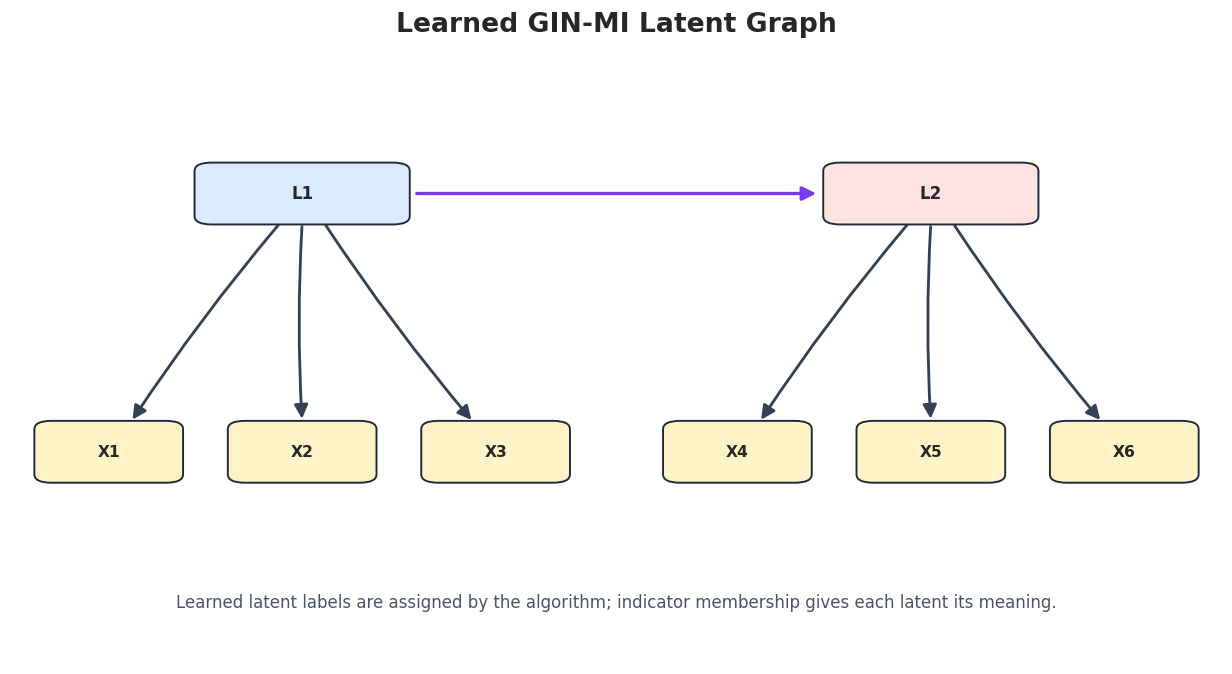

In [10]:
# Define reusable helpers for the Draw The Learned GIN-MI Measurement Graph section.
def draw_learned_gin_graph(cluster_summary, path, title="Learned GIN-MI Latent Graph"):
    """
    Idea: Visualize the latent clusters recovered by GIN alongside their learned ordering.
    
    Parameters
    ----------
    cluster_summary : object
        Table summarizing learned latent clusters.
    path : str or pathlib.Path
        Input or output path.
    title : str
        Title shown on the resulting plot or report.
    
    Returns
    -------
    None
        Draws the learned GIN latent-cluster graph directly on the Matplotlib axes.
    """
    fig, ax = plt.subplots(figsize=(13, 6.5))
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    cluster_summary = cluster_summary.sort_values("order_position").reset_index(drop=True)
    n_clusters = len(cluster_summary)
    latent_x = np.linspace(0.24, 0.76, n_clusters) if n_clusters > 1 else np.array([0.50])
    latent_positions = {}
    observed_positions = {}
    for i, row in cluster_summary.iterrows():
        latent = row["learned_latent"]
        x_center = latent_x[i]
        latent_positions[latent] = (x_center, 0.78)
        members = row["members"].split(", ")
        offsets = np.linspace(-0.16, 0.16, len(members)) if len(members) > 1 else np.array([0.0])
        for member, offset in zip(members, offsets):
            observed_positions[member] = (x_center + offset, 0.35)
    ordered_latents = cluster_summary["learned_latent"].tolist()
    for left, right in zip(ordered_latents[:-1], ordered_latents[1:]):
        add_arrow(ax, latent_positions[left], latent_positions[right], color="#7c3aed", lw=2.0)
    for latent in ordered_latents:
        member_labels = cluster_summary.loc[cluster_summary["learned_latent"].eq(latent), "members"].iloc[0].split(", ")
        for member in member_labels:
            add_arrow(ax, latent_positions[latent], observed_positions[member], rad=0.03)
    palette = ["#dbeafe", "#fee2e2", "#dcfce7", "#ede9fe"]
    for i, latent in enumerate(ordered_latents):
        add_box(ax, latent_positions[latent], latent, palette[i % len(palette)], width=0.15)
    for member, xy in observed_positions.items():
        add_box(ax, xy, member, "#fef3c7", width=0.095, fontsize=9.3)
    ax.text(
        0.5,
        0.10,
        "Learned latent labels are assigned by the algorithm; indicator membership gives each latent its meaning.",
        ha="center",
        va="center",
        fontsize=10,
        color="#475569",
    )
    ax.set_title(title, pad=18, fontsize=16, fontweight="bold")
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
draw_learned_gin_graph(gin_mi_cluster_summary, FIGURE_DIR / f"{NOTEBOOK_PREFIX}_gin_mi_learned_graph.png")


The learned graph has the same high-level shape as the true graph: one latent group for the first three indicators and one latent group for the last three indicators.




### Compare with the Independence-Test GIN Variant

`causal-learn` also exposes `GIN`, which can use `hsic` or `kci` independence testing. On small examples, this version can be more conservative about which indicators it assigns to a cluster. We run the `hsic` option here because it is quick enough for an interactive walkthrough.


In [11]:
start_time = time.perf_counter()
gin_hsic_graph, gin_hsic_order = GIN(observed_df.to_numpy(), indep_test_method="hsic", alpha=0.05)
gin_hsic_elapsed = time.perf_counter() - start_time
gin_hsic_cluster_table, gin_hsic_cluster_summary, gin_hsic_metrics = summarize_cluster_quality(gin_hsic_order)
gin_hsic_metrics["method"] = "GIN_hsic"
gin_hsic_metrics["elapsed_seconds"] = gin_hsic_elapsed
gin_hsic_edges = graph_edges_to_table(gin_hsic_graph, "GIN_hsic")
gin_hsic_cluster_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_gin_hsic_cluster_assignments.csv", index=False)
gin_hsic_cluster_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_gin_hsic_cluster_summary.csv", index=False)
gin_hsic_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_gin_hsic_metrics.csv", index=False)
gin_hsic_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_gin_hsic_graph_edges.csv", index=False)
display(gin_hsic_cluster_table)
display(gin_hsic_cluster_summary)
display(gin_hsic_metrics.round(4))
display(gin_hsic_edges)


,learned_latent,order_position,observed_index,gin_label,observed_variable,true_latent
0,L1,1,0,X1,X1_need_search,latent_need
1,L1,1,1,X2,X2_need_depth,latent_need
2,L1,1,2,X3,X3_need_variety,latent_need
3,L1,1,3,X4,X4_value_click,latent_value
4,L1,1,5,X6,X6_value_return,latent_value


,learned_latent,order_position,members,member_names,majority_true_latent,cluster_size,cluster_purity
0,L1,1,"X1, X2, X3, X4, X6","X1_need_search, X2_need_depth, X3_need_variety, X4_value_click, X6_value_return",latent_need,5,0.6


,n_clusters,adjusted_rand_index,mean_cluster_purity,order_matches_truth,learned_majority_order,method,elapsed_seconds
0,1,0.0,0.6,False,latent_need,GIN_hsic,0.7798


,method,edge
0,GIN_hsic,L1 --> X1
1,GIN_hsic,L1 --> X2
2,GIN_hsic,L1 --> X3
3,GIN_hsic,L1 --> X4
4,GIN_hsic,L1 --> X6


The HSIC-based run may assign fewer indicators than GIN-MI on this finite sample. That is a useful reminder that algorithm settings and independence tests affect the recovered measurement structure.


#### Method Comparison Table

The next table compares GIN-MI and HSIC-based GIN using cluster quality, latent order agreement, and runtime.


In [12]:
method_comparison = pd.concat([gin_mi_metrics, gin_hsic_metrics], ignore_index=True)
method_comparison = method_comparison[
    ["method", "n_clusters", "adjusted_rand_index", "mean_cluster_purity", "order_matches_truth", "learned_majority_order", "elapsed_seconds"]
]
method_comparison.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_method_comparison.csv", index=False)
display(method_comparison.round(4))


,method,n_clusters,adjusted_rand_index,mean_cluster_purity,order_matches_truth,learned_majority_order,elapsed_seconds
0,GIN_MI,2,1.0,1.0,True,latent_need -> latent_value,0.4250
1,GIN_hsic,1,0.0,0.6,False,latent_need,0.7798


This comparison separates cluster recovery from causal order recovery. In latent discovery, both pieces matter, and either one can become unstable.

That makes the comparison interpretable because differences across methods can be tied to estimator behavior while preprocessing and evaluation stay fixed.
<!-- result-implication-expanded -->


#### Plot Method Comparison

A simple bar plot helps compare cluster quality across the two GIN variants.


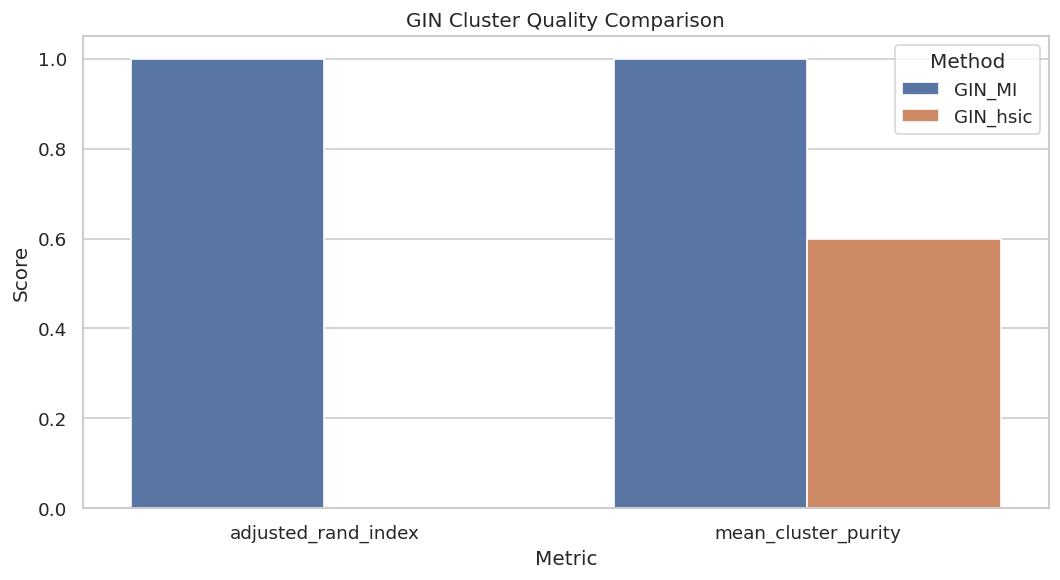

In [13]:
method_plot = method_comparison.melt(
    id_vars="method",
    value_vars=["adjusted_rand_index", "mean_cluster_purity"],
    var_name="metric",
    value_name="score",
)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=method_plot, x="metric", y="score", hue="method", ax=ax)
ax.set_title("GIN Cluster Quality Comparison")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(title="Method")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_method_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


GIN-MI is the cleaner baseline for this lesson. The HSIC version is still useful to show how a stricter independence-testing route can behave differently.


#### Sensitivity to Sample Size and Measurement Noise

Latent cluster recovery depends on having enough observations and strong enough indicators. We scan sample size and measurement noise to see when the recovered clusters remain stable.


In [14]:
sensitivity_rows = []
for n_samples in [120, 200, 300, 500]:
    for measurement_noise in [0.15, 0.30, 0.60, 0.90]:
        candidate_df, _, _ = simulate_latent_indicator_data(
            n_samples=n_samples,
            seed=RANDOM_SEED,
            measurement_noise=measurement_noise,
        )
        start_time = time.perf_counter()
        _, candidate_order = GIN_MI(candidate_df.to_numpy())
        elapsed = time.perf_counter() - start_time
        _, _, metrics = summarize_cluster_quality(candidate_order)
        row = metrics.iloc[0].to_dict()
        row.update(
            {
                "n_samples": n_samples,
                "measurement_noise": measurement_noise,
                "elapsed_seconds": elapsed,
            }
        )
        sensitivity_rows.append(row)
noise_sensitivity = pd.DataFrame(sensitivity_rows)
noise_sensitivity.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_sample_noise_sensitivity.csv", index=False)
display(noise_sensitivity[["n_samples", "measurement_noise", "n_clusters", "adjusted_rand_index", "mean_cluster_purity", "order_matches_truth", "elapsed_seconds"]].round(4))


,n_samples,measurement_noise,n_clusters,adjusted_rand_index,mean_cluster_purity,order_matches_truth,elapsed_seconds
0,120,0.15,2,1.0000,1.000,True,0.0465
1,120,0.30,2,1.0000,1.000,True,0.0464
2,120,0.60,2,0.3243,0.875,True,0.0453
3,120,0.90,2,0.3243,0.875,True,0.0467
4,200,0.15,2,1.0000,1.000,True,0.0883
5,200,0.30,2,1.0000,1.000,False,0.0837
6,200,0.60,2,1.0000,1.000,False,0.0866
7,200,0.90,2,0.3243,0.875,True,0.0863
8,300,0.15,2,1.0000,1.000,True,0.1602
9,300,0.30,2,1.0000,1.000,True,0.1636


The grid shows the main practical pattern: with more observations, the correct indicator clusters are more robust to noisy measurement. With very small samples and high noise, clusters can mix indicators from different latent parents.


#### Plot Sample and Noise Sensitivity

The heatmap shows adjusted Rand index across the sample-size and noise grid. Values near one mean the recovered indicator clusters match the true groups.


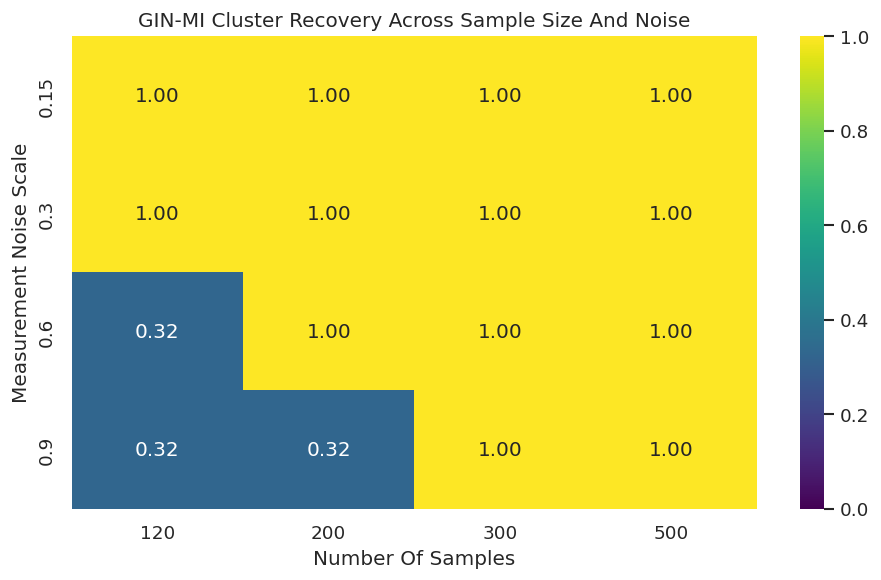

In [15]:
ari_heatmap = noise_sensitivity.pivot(index="measurement_noise", columns="n_samples", values="adjusted_rand_index")
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(ari_heatmap, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1, ax=ax)
ax.set_title("GIN-MI Cluster Recovery Across Sample Size And Noise")
ax.set_xlabel("Number Of Samples")
ax.set_ylabel("Measurement Noise Scale")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_sample_noise_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()


The heatmap makes the failure region easy to see. A latent discovery report should include this kind of stress check whenever the strength of the indicators is uncertain.


### Sensitivity to Non-Gaussian Assumptions

GIN is motivated by linear non-Gaussian latent-variable structure. The next step compares Laplace and Gaussian noise across several random seeds. Cluster recovery can still look good under Gaussian noise in this simple example, but the latent order becomes less stable.


In [16]:
noise_family_rows = []
for distribution in ["laplace", "gaussian"]:
    for seed in range(8):
        candidate_df, _, _ = simulate_latent_indicator_data(
            n_samples=300,
            seed=seed,
            measurement_noise=0.25,
            latent_noise_distribution=distribution,
        )
        start_time = time.perf_counter()
        _, candidate_order = GIN_MI(candidate_df.to_numpy())
        elapsed = time.perf_counter() - start_time
        _, _, metrics = summarize_cluster_quality(candidate_order)
        row = metrics.iloc[0].to_dict()
        row.update({"noise_family": distribution, "seed": seed, "elapsed_seconds": elapsed})
        noise_family_rows.append(row)
noise_family_sensitivity = pd.DataFrame(noise_family_rows)
noise_family_sensitivity.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_noise_family_sensitivity.csv", index=False)
display(noise_family_sensitivity[["noise_family", "seed", "adjusted_rand_index", "mean_cluster_purity", "order_matches_truth", "learned_majority_order", "elapsed_seconds"]].round(4))


,noise_family,seed,adjusted_rand_index,mean_cluster_purity,order_matches_truth,learned_majority_order,elapsed_seconds
0,laplace,0,1.0,1.0,True,latent_need -> latent_value,0.1611
1,laplace,1,1.0,1.0,True,latent_need -> latent_value,0.1622
2,laplace,2,1.0,1.0,True,latent_need -> latent_value,0.1645
3,laplace,3,1.0,1.0,True,latent_need -> latent_value,0.1654
4,laplace,4,1.0,1.0,True,latent_need -> latent_value,0.1641
5,laplace,5,1.0,1.0,True,latent_need -> latent_value,0.1654
6,laplace,6,1.0,1.0,True,latent_need -> latent_value,0.1646
7,laplace,7,1.0,1.0,True,latent_need -> latent_value,0.1595
8,gaussian,0,1.0,1.0,True,latent_need -> latent_value,0.1600
9,gaussian,1,1.0,1.0,True,latent_need -> latent_value,0.1589


This table separates two outcomes. The indicator clusters can remain correct while the latent order flips across seeds, especially when the distributional assumptions are weakened.


#### Plot Latent Order Stability

The next plot counts how often the learned majority order matches the true latent order for each noise family.


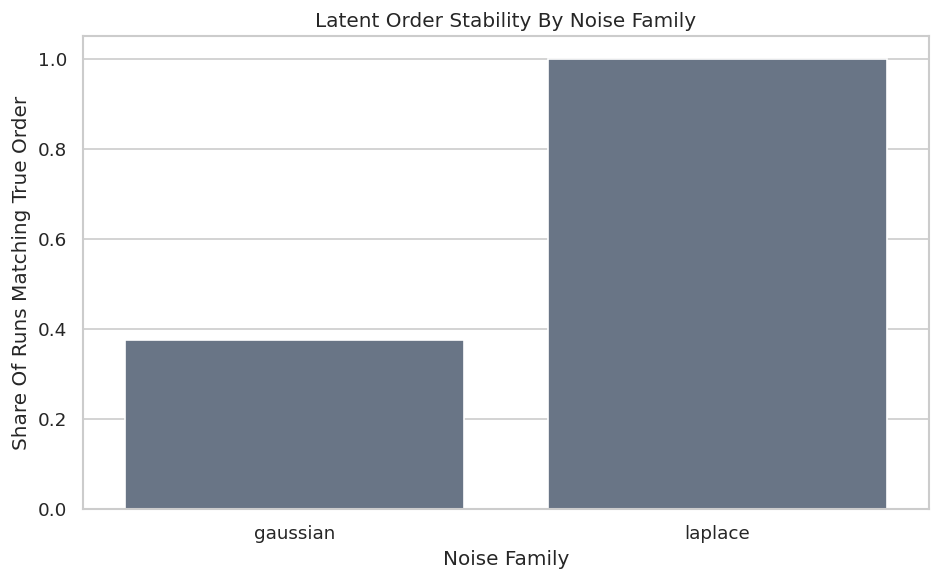

,noise_family,runs,ari_mean,order_match_rate
0,gaussian,8,1.0,0.375
1,laplace,8,1.0,1.000


In [17]:
order_stability = noise_family_sensitivity.groupby("noise_family", as_index=False).agg(
    runs=("seed", "count"),
    ari_mean=("adjusted_rand_index", "mean"),
    order_match_rate=("order_matches_truth", "mean"),
)
order_stability.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_noise_family_order_stability.csv", index=False)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=order_stability, x="noise_family", y="order_match_rate", color="#64748b", ax=ax)
ax.set_title("Latent Order Stability By Noise Family")
ax.set_xlabel("Noise Family")
ax.set_ylabel("Share Of Runs Matching True Order")
ax.set_ylim(0, 1.05)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_noise_family_order_stability.png", dpi=160, bbox_inches="tight")
plt.show()
display(order_stability.round(4))


The plot shows why cluster recovery and latent order recovery should be reported separately. A clean clustering result still needs direction stability checks among the latent constructs.


#### Cross-Loading Stress Test

A clean measurement model says each indicator belongs to one latent parent. Real indicators often cross-load: one observed variable partly measures more than one hidden construct. The next test gradually contaminates one downstream indicator with the upstream latent factor.


In [18]:
cross_loading_rows = []
for cross_loading_strength in [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]:
    candidate_df, _, loading_info = simulate_latent_indicator_data(
        n_samples=300,
        seed=RANDOM_SEED,
        measurement_noise=0.25,
        cross_loading_strength=cross_loading_strength,
    )
    start_time = time.perf_counter()
    _, candidate_order = GIN_MI(candidate_df.to_numpy())
    elapsed = time.perf_counter() - start_time
    cluster_table, cluster_summary, metrics = summarize_cluster_quality(candidate_order)
    row = metrics.iloc[0].to_dict()
    row.update(
        {
            "cross_loading_strength": cross_loading_strength,
            "elapsed_seconds": elapsed,
            "learned_clusters": " | ".join(cluster_summary["members"].tolist()),
        }
    )
    cross_loading_rows.append(row)
cross_loading_sensitivity = pd.DataFrame(cross_loading_rows)
cross_loading_sensitivity.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_cross_loading_sensitivity.csv", index=False)
display(cross_loading_sensitivity[["cross_loading_strength", "n_clusters", "adjusted_rand_index", "mean_cluster_purity", "order_matches_truth", "learned_clusters"]].round(4))


,cross_loading_strength,n_clusters,adjusted_rand_index,mean_cluster_purity,order_matches_truth,learned_clusters
0,0.0,2,1.0000,1.000,True,"X1, X2, X3 | X4, X5, X6"
1,0.5,2,1.0000,1.000,True,"X1, X2, X3 | X4, X5, X6"
2,1.0,2,1.0000,1.000,True,"X1, X2, X3 | X4, X5, X6"
3,1.5,2,0.3243,0.875,True,"X1, X2, X3, X6 | X4, X5"
4,2.0,2,0.3243,0.875,True,"X1, X2, X3, X6 | X4, X5"
5,3.0,2,0.3243,0.875,True,"X1, X2, X3, X6 | X4, X5"


Once the cross-loading becomes large, the contaminated indicator moves into the wrong learned cluster. This is a useful failure mode because it matches a common real-data problem: proxy variables often measure multiple constructs.


#### Plot Cross-Loading Sensitivity

The plot shows how cluster quality changes as one indicator becomes less clean.


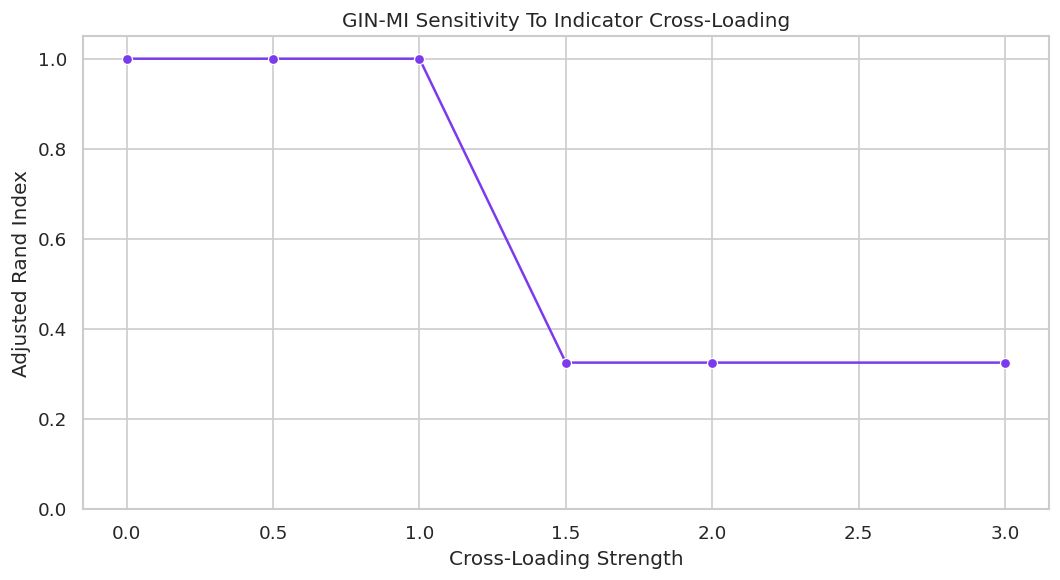

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(
    data=cross_loading_sensitivity,
    x="cross_loading_strength",
    y="adjusted_rand_index",
    marker="o",
    color="#7c3aed",
    ax=ax,
)
ax.set_title("GIN-MI Sensitivity To Indicator Cross-Loading")
ax.set_xlabel("Cross-Loading Strength")
ax.set_ylabel("Adjusted Rand Index")
ax.set_ylim(0, 1.05)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_cross_loading_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()


The decline marks the point where the clean single-parent measurement assumption is no longer a good description of the observed indicators.

The lesson is robustness: a publishable conclusion should not hinge on one arbitrary threshold, one lucky sample split, or one narrow tuning choice.
<!-- result-implication-expanded -->




#### Runtime Sketch

GIN-MI is fast on six observed variables, but runtime still grows with sample size and the number of observed indicators. This small benchmark varies the sample size for the baseline six-indicator model.


In [20]:
runtime_rows = []
for n_samples in [100, 200, 500, 1_000]:
    candidate_df, _, _ = simulate_latent_indicator_data(n_samples=n_samples, seed=RANDOM_SEED)
    start_time = time.perf_counter()
    GIN_MI(candidate_df.to_numpy())
    elapsed = time.perf_counter() - start_time
    runtime_rows.append({"n_samples": n_samples, "n_observed_variables": len(OBSERVED_VARIABLES), "elapsed_seconds": elapsed})
runtime_table = pd.DataFrame(runtime_rows)
runtime_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_runtime_sketch.csv", index=False)
display(runtime_table.round(4))


,n_samples,n_observed_variables,elapsed_seconds
0,100,6,0.0422
1,200,6,0.0865
2,500,6,0.4265
3,1000,6,2.0410


This is a local runtime sketch, not a universal benchmark. It does show why the tutorial keeps the sensitivity grid small.

That makes the comparison interpretable because differences across methods can be tied to estimator behavior while preprocessing and evaluation stay fixed.
<!-- result-implication-expanded -->


#### Plot Runtime Sketch

The line plot gives a quick sense of the local cost as the number of rows increases.


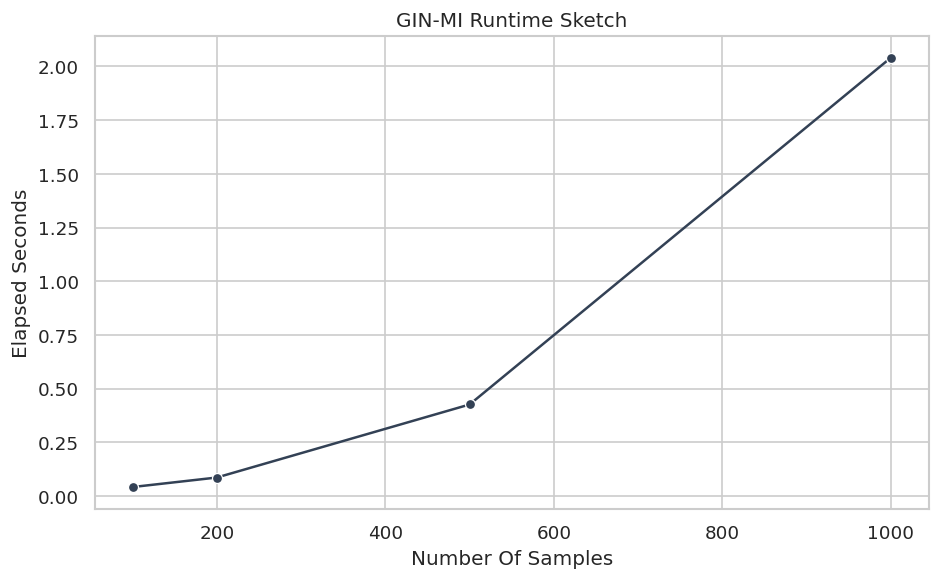

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=runtime_table, x="n_samples", y="elapsed_seconds", marker="o", color="#334155", ax=ax)
ax.set_title("GIN-MI Runtime Sketch")
ax.set_xlabel("Number Of Samples")
ax.set_ylabel("Elapsed Seconds")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_runtime_sketch.png", dpi=160, bbox_inches="tight")
plt.show()


The runtime remains manageable here. With many observed variables, the cluster search can become the expensive part.

The lesson is robustness: a publishable conclusion should not hinge on one arbitrary threshold, one lucky sample split, or one narrow tuning choice.
<!-- result-implication-expanded -->





## Reporting and Takeaways

### Practical Reporting Checklist

A GIN analysis should report the measurement assumptions as clearly as the graph output. The next checklist records what a reader needs to know before trusting a latent discovery result.


| item | what_to_report | why_it_matters |
| --- | --- | --- |
| Observed indicator map | Which measured columns are candidate indicators and how they were selected. | GIN learns latent groups from observed indicators; irrelevant columns can distort clusters. |
| Measurement model assumption | Whether indicators are expected to have one latent parent or possible cross-loadings. | Cross-loaded indicators can move into the wrong learned cluster. |
| Distributional assumption | Whether non-Gaussianity is plausible or checked. | The method is designed for linear non-Gaussian latent-variable structure. |
| Cluster quality diagnostics | Cluster membership, cluster size, stability, and domain meaning. | The latent labels are arbitrary until the indicator membership gives them meaning. |
| Latent order stability | Whether the learned order changes across seeds, samples, or plausible preprocessing choices. | Correct clusters do not guarantee a stable causal order among latent constructs. |
| Sensitivity checks | Noise, weak indicators, cross-loading, alternative tests, and sample-size checks. | Latent discovery can look clean in one specification and fragile in another. |
| Claim strength | Whether the output is used as a candidate measurement graph or a causal conclusion. | Latent-variable discovery needs external support before strong claims are made. |


The checklist is conservative. GIN can be a powerful way to reason about hidden constructs, but the assumptions must travel with the result.


## Summary


The lesson leaves us with a reusable pattern: define candidate indicators, learn latent clusters, score or audit cluster quality, then stress-test the measurement assumptions before treating the latent graph as more than a hypothesis.
